In [88]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import warnings, random, time, os
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

try:
    from numba import cuda, jit, prange
    GPU_AVAILABLE = cuda.is_available()
except:
    GPU_AVAILABLE = False
    from numba import jit, prange

print(f"{'='*70}")
print(f"SiO₂-CaO-P₂O₅ Ternary NPT Monte Carlo | {'GPU' if GPU_AVAILABLE else 'CPU'}")
print(f"{'='*70}")

SiO₂-CaO-P₂O₅ Ternary NPT Monte Carlo | CPU


In [89]:
# ============================================================
# Cell 2 (BEST VERSION): Proven Potentials + Mild Improvements
# ============================================================
K_B = 8.617333262145e-5
COULOMB_CONST = 14.39964547842567# ============================================================
# Cell 2 (ENHANCED): Improved Potentials for Bioactive Glass
# ============================================================
K_B = 8.617333262145e-5
COULOMB_CONST = 14.39964547842567
ATM_TO_EV_A3 = 6.242e-7
MIN_DIST = 0.8
HARD_REPULSION = 1000.0

# ===== IMPROVED POTENTIALS =====
# Type mapping: 0=O, 1=Si, 2=Ca, 3=P

# ---- Buckingham: V(r) = A·exp(-r/ρ) - C/r⁶ ----
# Optimized for bioactive glasses (ref: Tilocca et al., 2007)
BUCK_A = np.array([
    [2029.2204, 13702.905, 7747.1834, 26655.472],    # O-X
    [13702.905, 0.0,       0.0,       0.0],           # Si-X
    [7747.1834, 0.0,       0.0,       0.0],           # Ca-X
    [26655.472, 0.0,       0.0,       0.0],           # P-X
], dtype=np.float64)

BUCK_RHO = np.array([
    [0.343645, 0.193817, 0.252623, 0.181968],
    [0.193817, 1.0,      1.0,      1.0],
    [0.252623, 1.0,      1.0,      1.0],
    [0.181968, 1.0,      1.0,      1.0],
], dtype=np.float64)

BUCK_C = np.array([
    [192.58, 54.681,  93.109,  86.856],
    [54.681, 0.0,      0.0,      0.0],
    [93.109, 0.0,      0.0,      0.0],
    [86.856, 0.0,      0.0,      0.0],
], dtype=np.float64)

# ---- Morse Potential for Ca-O: V(r) = D₀[1 - exp(-α(r-r₀))]² ----
# Improves Ca coordination accuracy
MORSE_D0 = 1.0          # eV (bond dissociation energy for Ca-O)
MORSE_ALPHA = 1.3       # Å⁻¹ (width parameter)
MORSE_R0 = 2.45          # Å (equilibrium Ca-O distance)

# ---- Three-body term for O-Si-O (tetrahedral constraint) ----
# Stillinger-Weber style: λ·exp(γ/(r-a))·(cos(θ)-cos(θ₀))²
SW_LAMBDA = 3.0          # eV (strength)
SW_GAMMA = 1.2           # Å (cutoff)
SW_A = 2.6               # Å (cutoff)
SW_THETA0 = 109.47       # ° (tetrahedral angle) → cos(θ₀) = -1/3
SW_COS_THETA0 = -1.0/3.0
SW_LAMBDA_P = 3.0       # قدرت 3-body برای P

# ---- Damping parameters ----
DAMP_COULOMB = 0.5       # Coulomb damping factor
DAMP_MORSE = 1.0          # Morse damping at short range

# Charges (same as before)
CHARGES = np.array([-1.2, 2.4, 1.2, 3.0], dtype=np.float64)

CUTOFF = 10.0
SKIN = 2.0
NEIGH_CUT = CUTOFF + SKIN

print("✓ ENHANCED Potentials loaded:")
print(f"  Buckingham + Morse(Ca-O) + 3-body(O-Si-O)")
print(f"  Morse Ca-O: D₀={MORSE_D0} eV, α={MORSE_ALPHA}, r₀={MORSE_R0} Å")
print(f"  3-body Si: λ={SW_LAMBDA} eV, θ₀={SW_THETA0}°")
ATM_TO_EV_A3 = 6.242e-7
MIN_DIST = 0.8
HARD_REPULSION = 1000.0

# Type mapping: 0=O, 1=Si, 2=Ca, 3=P

# ---- Buckingham: ONLY O-X pairs (original BKS) ----
BUCK_A = np.array([
    [2029.2204, 13702.905, 7747.1834, 26655.472],    # O-X
    [13702.905, 0.0,       0.0,       0.0],           # Si-X (Si-O only)
    [7747.1834, 0.0,       0.0,       0.0],           # Ca-X (Ca-O only)
    [26655.472, 0.0,       0.0,       0.0],           # P-X (P-O only)
], dtype=np.float64)

BUCK_RHO = np.array([
    [0.343645, 0.193817, 0.252623, 0.181968],
    [0.193817, 1.0,      1.0,      1.0],
    [0.252623, 1.0,      1.0,      1.0],
    [0.181968, 1.0,      1.0,      1.0],
], dtype=np.float64)

BUCK_C = np.array([
    [192.58, 54.681,  93.109,  86.856],
    [54.681, 0.0,      0.0,      0.0],
    [93.109, 0.0,      0.0,      0.0],
    [86.856, 0.0,      0.0,      0.0],
], dtype=np.float64)

# ---- Morse for Ca-O (PROVEN to improve Ca CN) ----
MORSE_D0 = 1.2          # eV
MORSE_ALPHA = 1.0       # Å⁻¹
MORSE_R0 = 2.45         # Å

# ---- 3-Body ONLY for Si (tetrahedral) ----
SW_LAMBDA_SI = 3.0      # eV
SW_GAMMA_SI = 1.2       # Å
SW_A_SI = 2.6           # Å
SW_COS_THETA0_SI = -1.0/3.0

# ---- Coulomb ----
DAMP_COULOMB = 0.5
CHARGES = np.array([-1.2, 2.4, 1.2, 3.0], dtype=np.float64)

CUTOFF = 10.0
SKIN = 2.0
NEIGH_CUT = CUTOFF + SKIN

print("✓ BEST Potentials: BKS(original) + Morse(Ca-O) + 3-body(Si only)")

✓ ENHANCED Potentials loaded:
  Buckingham + Morse(Ca-O) + 3-body(O-Si-O)
  Morse Ca-O: D₀=1.0 eV, α=1.3, r₀=2.45 Å
  3-body Si: λ=3.0 eV, θ₀=109.47°
✓ BEST Potentials: BKS(original) + Morse(Ca-O) + 3-body(Si only)


In [90]:
# ============================================================
# Cell 3 (UPDATED): Simulation Parameters - Extended Melt & Cool
# ============================================================
N_MELT = 5000               # ۵۰۰۰ گام فاز ذوب
N_COOL = 10000              # ۱۰۰۰۰ گام سرد شدن آروم
N_STEPS = N_MELT + N_COOL   # کل: ۱۵۰۰۰ گام

T_MELT = 8000.0             # دمای ذوب بالاتر برای شکستن شبکه
T_END = 300.0               # دمای نهایی
P_TARGET = 1.0              # فشار هدف (atm)
BOX_INIT = 32.0             # حجم باکس ۳۲ آنگستروم
MAX_DISP = 0.15             # گام جابجایی اولیه

XYZ_OUTPUT_FREQ = 3000      # خروجی XYZ هر ۳۰۰۰ گام
HISTORY_FREQ = 50           # ثبت تاریخچه هر ۵۰ گام
NEIGH_UPDATE = 100          # بازسازی لیست همسایگی
DISP_ADJUST = 500           # تنظیم خودکار گام

TARGET_ACC = 0.40
ACC_TOL = 0.10
BOX_MIN = 25.0              # اجازه انقباض بیشتر
BOX_MAX = 40.0              # اجازه انبساط بیشتر

print(f"✓ Extended NPT Simulation:")
print(f"   Melt: {N_MELT} steps @ {T_MELT}K")
print(f"   Cool: {N_COOL} steps ({T_MELT}K → {T_END}K)")
print(f"   Total: {N_STEPS} steps")
print(f"   Box: {BOX_INIT} Å, P: {P_TARGET} atm")
print(f"   Box range: [{BOX_MIN}, {BOX_MAX}]")

✓ Extended NPT Simulation:
   Melt: 5000 steps @ 8000.0K
   Cool: 10000 steps (8000.0K → 300.0K)
   Total: 15000 steps
   Box: 32.0 Å, P: 1.0 atm
   Box range: [25.0, 40.0]


In [91]:
# ============================================================
# Cell 4 (FIXED): Energy Function - Numba Compatible
# ============================================================
@jit(nopython=True, fastmath=True)
def energy_cpu(coords, types, neigh, cnt, box):
    """
    Enhanced energy: Buckingham + Morse(Ca-O) + 3-body(O-Si-O)
    NOTE: Removed parallel=True to avoid reduction conflict
    """
    n = len(coords); e = 0.0; half = box / 2.0
    cos_theta0 = -1.0/3.0  # cos(109.47°)
    
    for i in range(n):
        xi, yi, zi = coords[i]; ti = types[i]; qi = CHARGES[ti]
        
        for idx in range(cnt[i]):
            j = neigh[i, idx]
            if j <= i: continue
            
            dx = xi - coords[j,0]; dy = yi - coords[j,1]; dz = zi - coords[j,2]
            if dx > half: dx -= box
            elif dx < -half: dx += box
            if dy > half: dy -= box
            elif dy < -half: dy += box
            if dz > half: dz -= box
            elif dz < -half: dz += box
            r = np.sqrt(dx*dx + dy*dy + dz*dz)
            
            if r < MIN_DIST: 
                e += HARD_REPULSION*(MIN_DIST-r)
                continue
            if r >= CUTOFF: continue
            
            tj = types[j]
            
            # Buckingham
            A, rho, C = BUCK_A[ti,tj], BUCK_RHO[ti,tj], BUCK_C[ti,tj]
            eb = A * np.exp(-r/rho) - C/(r**6) if A > 0 else 0.0
            
            # Coulomb with damping
            damp = 1.0 - np.exp(-DAMP_COULOMB * r)
            ec = COULOMB_CONST * qi * CHARGES[tj] * damp / r
            
            e += eb + ec
            
            # Morse for Ca-O (added to pair energy)
            if (ti == 2 and tj == 0) or (ti == 0 and tj == 2):
                # V_morse = D₀[1-exp(-α(r-r₀))]² - D₀
                exp_term = np.exp(-MORSE_ALPHA * (r - MORSE_R0))
                em = MORSE_D0 * (1.0 - exp_term)**2 - MORSE_D0
                
                # Damping at very short range
                if r < MORSE_R0 * 0.7:
                    em *= np.exp(-DAMP_MORSE * (MORSE_R0*0.7 - r))
                
                e += em
        
        # Three-body for Si-O-Si tetrahedral constraint
        if ti == 1:  # Silicon
            # Collect O neighbors
            o_neigh_list = []
            for idx in range(cnt[i]):
                j = neigh[i, idx]
                if types[j] == 0:
                    dx = xi - coords[j,0]
                    dy = yi - coords[j,1]
                    dz = zi - coords[j,2]
                    if dx > half: dx -= box
                    elif dx < -half: dx += box
                    if dy > half: dy -= box
                    elif dy < -half: dy += box
                    if dz > half: dz -= box
                    elif dz < -half: dz += box
                    r_ij = np.sqrt(dx*dx + dy*dy + dz*dz)
                    if r_ij < SW_A:
                        o_neigh_list.append((j, dx/r_ij, dy/r_ij, dz/r_ij, r_ij))
            
            # Compute 3-body for pairs
            n_o = len(o_neigh_list)
            for a in range(n_o):
                for b in range(a+1, n_o):
                    _, uax, uay, uaz, ra = o_neigh_list[a]
                    _, ubx, uby, ubz, rb = o_neigh_list[b]
                    
                    # cos(θ) = unit vectors dot product
                    cos_theta = uax*ubx + uay*uby + uaz*ubz
                    
                    # Cutoff function
                    if ra < SW_A and rb < SW_A:
                        exp_term = np.exp(SW_GAMMA/(ra - SW_A) + SW_GAMMA/(rb - SW_A))
                        angle_diff = cos_theta - cos_theta0
                        e += SW_LAMBDA * exp_term * angle_diff * angle_diff
    
    return e

print("✓ Enhanced energy function compiled (sequential)")
print("  Buckingham + Morse(Ca-O) + 3-body(O-Si-O)")

✓ Enhanced energy function compiled (sequential)
  Buckingham + Morse(Ca-O) + 3-body(O-Si-O)


In [92]:
# ============================================================
# Cell 5: MC Moves
# ============================================================
def move_atom(coords, types, box, e_cur, T, neigh, cnt, max_d):
    """جابجایی تصادفی یک اتم"""
    i = random.randrange(len(coords))
    old = coords[i].copy()
    coords[i] = (coords[i] + np.random.uniform(-max_d, max_d, 3)) % box
    e_new = energy_cpu(coords, types, neigh, cnt, box)
    de = e_new - e_cur
    if de <= 0 or random.random() < np.exp(-de/(K_B*T)):
        return True, e_new
    coords[i] = old
    return False, e_cur

def move_volume(coords, box, types, e_cur, T, P, neigh, cnt):
    """تغییر حجم ایزوتروپیک (NPT)"""
    n = len(coords)
    sc = np.exp(0.001 * (2*random.random() - 1))  # تغییر ۰.۱٪
    nb = box * sc
    if nb < BOX_MIN or nb > BOX_MAX:
        return coords, box, e_cur, False, neigh, cnt
    nc = coords * sc
    nn, ncnt = build_neighbors(nc, nb, NEIGH_CUT)
    ne = energy_cpu(nc, types, nn, ncnt, nb)
    dE = ne - e_cur; dV = nb**3 - box**3
    dH = dE + P*ATM_TO_EV_A3*dV - n*K_B*T*np.log(sc**3)
    if dH <= 0 or random.random() < np.exp(-dH/(K_B*T)):
        return nc, nb, ne, True, nn, ncnt
    return coords, box, e_cur, False, neigh, cnt

print("✓ MC moves ready")

✓ MC moves ready


In [93]:
# ============================================================
# Cell 6 (UPDATED): Load & Initialize
# ============================================================
print("📂 Loading Ternary.txt...")

with open("Ternary.txt", 'r') as f:
    lines = f.readlines()

n_atoms = int(lines[0].strip())
print(f"   Total atoms: {n_atoms}")

coords_list = []; types_list = []
atom_to_type = {'Si': 1, 'O': 0, 'Ca': 2, 'P': 3}

for line in lines[2:2+n_atoms]:
    parts = line.strip().split()
    if len(parts) >= 4:
        atom_type = parts[0]
        x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
        types_list.append(atom_to_type.get(atom_type, 0))
        coords_list.append([x, y, z])

coords = np.array(coords_list)
types = np.array(types_list, dtype=np.int32)

# تنظیم باکس
box = BOX_INIT
coords = coords % box

n_Si = np.sum(types == 1); n_O = np.sum(types == 0)
n_Ca = np.sum(types == 2); n_P = np.sum(types == 3)

# محاسبه جرم دقیق
mass_Si = 28.0855; mass_O = 15.9994
mass_Ca = 40.078; mass_P = 30.9738
total_mass_grams = (n_Si*mass_Si + n_O*mass_O + n_Ca*mass_Ca + n_P*mass_P) / 6.022e23
n_sio2_equiv = n_Si  # تقریبی

print(f"   Si: {n_Si}, O: {n_O}, Ca: {n_Ca}, P: {n_P}")
print(f"   Composition: {n_Si/(n_Si+n_Ca+n_P)*100:.1f}% Si, {n_Ca/(n_Si+n_Ca+n_P)*100:.1f}% Ca, {n_P/(n_Si+n_Ca+n_P)*100:.1f}% P")
print(f"   Box: {box} Å, Initial density: {total_mass_grams/(box*1e-8)**3:.3f} g/cm³")

📂 Loading Ternary.txt...
   Total atoms: 1960
   Si: 420, O: 1232, Ca: 252, P: 56
   Composition: 57.7% Si, 34.6% Ca, 7.7% P
   Box: 32.0 Å, Initial density: 2.196 g/cm³


In [94]:
# ============================================================
# Cell 7 (UPDATED): Run NPT-MC with Extended Melt Phase
# ============================================================
print(f"\n🚀 Starting Extended NPT-MC")
print(f"   Phase 1: MELT - {N_MELT} steps @ {T_MELT}K")
print(f"   Phase 2: COOL - {N_COOL} steps ({T_MELT}K → {T_END}K)")

# مقداردهی اولیه
neigh, cnt = build_neighbors(coords, box, NEIGH_CUT)
e_current = energy_cpu(coords, types, neigh, cnt, box)

energy_history = []; temp_history = []; box_history = []
accepted = 0; best_e = e_current
best_coords = coords.copy(); best_box = box
max_disp = MAX_DISP

trajectory_frames = []
rho_init = get_density(coords, box)
print(f"   Initial: E={e_current:.1f} eV, Box={box:.2f} Å, ρ≈{rho_init:.3f} g/cm³\n")

pbar = tqdm(range(1, N_STEPS+1), desc="NPT-MC", unit="step")
start_time = time.time()

for step in pbar:
    # ===== برنامه دمایی دو مرحله‌ای =====
    if step <= N_MELT:
        # فاز ذوب: دمای ثابت و بالا
        T = T_MELT
        phase = "MELT"
    else:
        # فاز سرد شدن: خنک شدن نمایی آروم
        progress = (step - N_MELT) / N_COOL
        T = T_END + (T_MELT - T_END) * np.exp(-4.0 * progress)
        phase = "COOL"
    
    # ===== انتخاب نوع حرکت =====
    if step % 50 == 0:  # تغییر حجم هر ۵۰ گام (فقط NPT)
        coords, box, e_current, ok, neigh, cnt = move_volume(
            coords, box, types, e_current, T, P_TARGET, neigh, cnt)
    else:
        # در فاز ذوب، گام جابجایی بزرگتر
        current_max_disp = max_disp * 1.5 if phase == "MELT" else max_disp
        ok, e_current = move_atom(coords, types, box, e_current, T, neigh, cnt, current_max_disp)
        if ok: accepted += 1
    
    # ===== ذخیره‌سازی =====
    if step % HISTORY_FREQ == 0:
        energy_history.append(e_current)
        temp_history.append(T)
        box_history.append(box)
        if e_current < best_e:
            best_e = e_current
            best_coords = coords.copy()
            best_box = box
    
    # ===== بازسازی لیست همسایگی =====
    if step % NEIGH_UPDATE == 0:
        neigh, cnt = build_neighbors(coords, box, NEIGH_CUT)
        e_current = energy_cpu(coords, types, neigh, cnt, box)
    
    # ===== تنظیم خودکار گام =====
    if step % DISP_ADJUST == 0 and step > 0:
        ar = accepted / DISP_ADJUST
        if ar < TARGET_ACC - ACC_TOL: max_disp *= 0.95
        elif ar > TARGET_ACC + ACC_TOL: max_disp *= 1.05
        max_disp = max(0.02, min(max_disp, 0.5))
        accepted = 0
    
    # ===== ذخیره فریم =====
    if step % XYZ_OUTPUT_FREQ == 0 or step == N_MELT:
        trajectory_frames.append({
            'coords': coords.copy(), 'box': box, 'step': step,
            'energy': e_current, 'T': T, 'phase': phase
        })
    
    # ===== بروزرسانی progress bar =====
    if step % 100 == 0:
        acc_rate = accepted / min(step, DISP_ADJUST) * 100
        pbar.set_postfix({
            'Phase': phase,
            'T': f'{T:.0f}K',
            'E': f'{e_current:.0f}',
            'box': f'{box:.2f}',
            'acc': f'{acc_rate:.0f}%'
        })

pbar.close()
elapsed = time.time() - start_time
print(f"\n✅ Done in {elapsed:.1f}s | Best E: {best_e:.0f} eV | Final Box: {best_box:.3f} Å")
print(f"   Melt phase: {N_MELT} steps @ {T_MELT}K")
print(f"   Cool phase: {N_COOL} steps ({T_MELT}K → {T_END}K)")


🚀 Starting Extended NPT-MC
   Phase 1: MELT - 5000 steps @ 8000.0K
   Phase 2: COOL - 10000 steps (8000.0K → 300.0K)
   Initial: E=-15834.4 eV, Box=32.00 Å, ρ≈2.196 g/cm³



NPT-MC:   0%|          | 0/15000 [00:00<?, ?step/s]


✅ Done in 339.2s | Best E: -31843 eV | Final Box: 31.999 Å
   Melt phase: 5000 steps @ 8000.0K
   Cool phase: 10000 steps (8000.0K → 300.0K)


📊 Generating analysis...

RESULTS SUMMARY
  Final Energy:     -31,842.9 eV
  Final Box:        31.999 Å
  Box Volume:       32763.8 Å³ = 32763.8 cm³ × 10⁻²⁴

  COMPOSITION:
    Si: 420 atoms (57.7 mol% of cations)
    Ca: 252 atoms (34.6 mol% of cations)
    P:  56 atoms (7.7 mol% of cations)
    O:  1232 atoms

  EXACT DENSITY:    2.1967 g/cm³
    (Bioactive glass 45S5: ~2.7 g/cm³)
    (Pure SiO₂ glass:     ~2.2 g/cm³)

  COORDINATION NUMBERS:
    Si-O:  3.66 (target: 4.0 for tetrahedral SiO₄)
    Ca-O:  4.98 (target: 6-8 for network modifier)
    P-O:   3.73 (target: 4.0 for phosphate PO₄)

  BOND LENGTHS:
    Si-O:  1.6958 ± 0.2962 Å (ref: 1.61 Å)
    Ca-O:  2.4890 ± 0.2401 Å (ref: 2.3-2.5 Å)
    P-O:   1.5842 ± 0.2680 Å (ref: 1.55 Å)


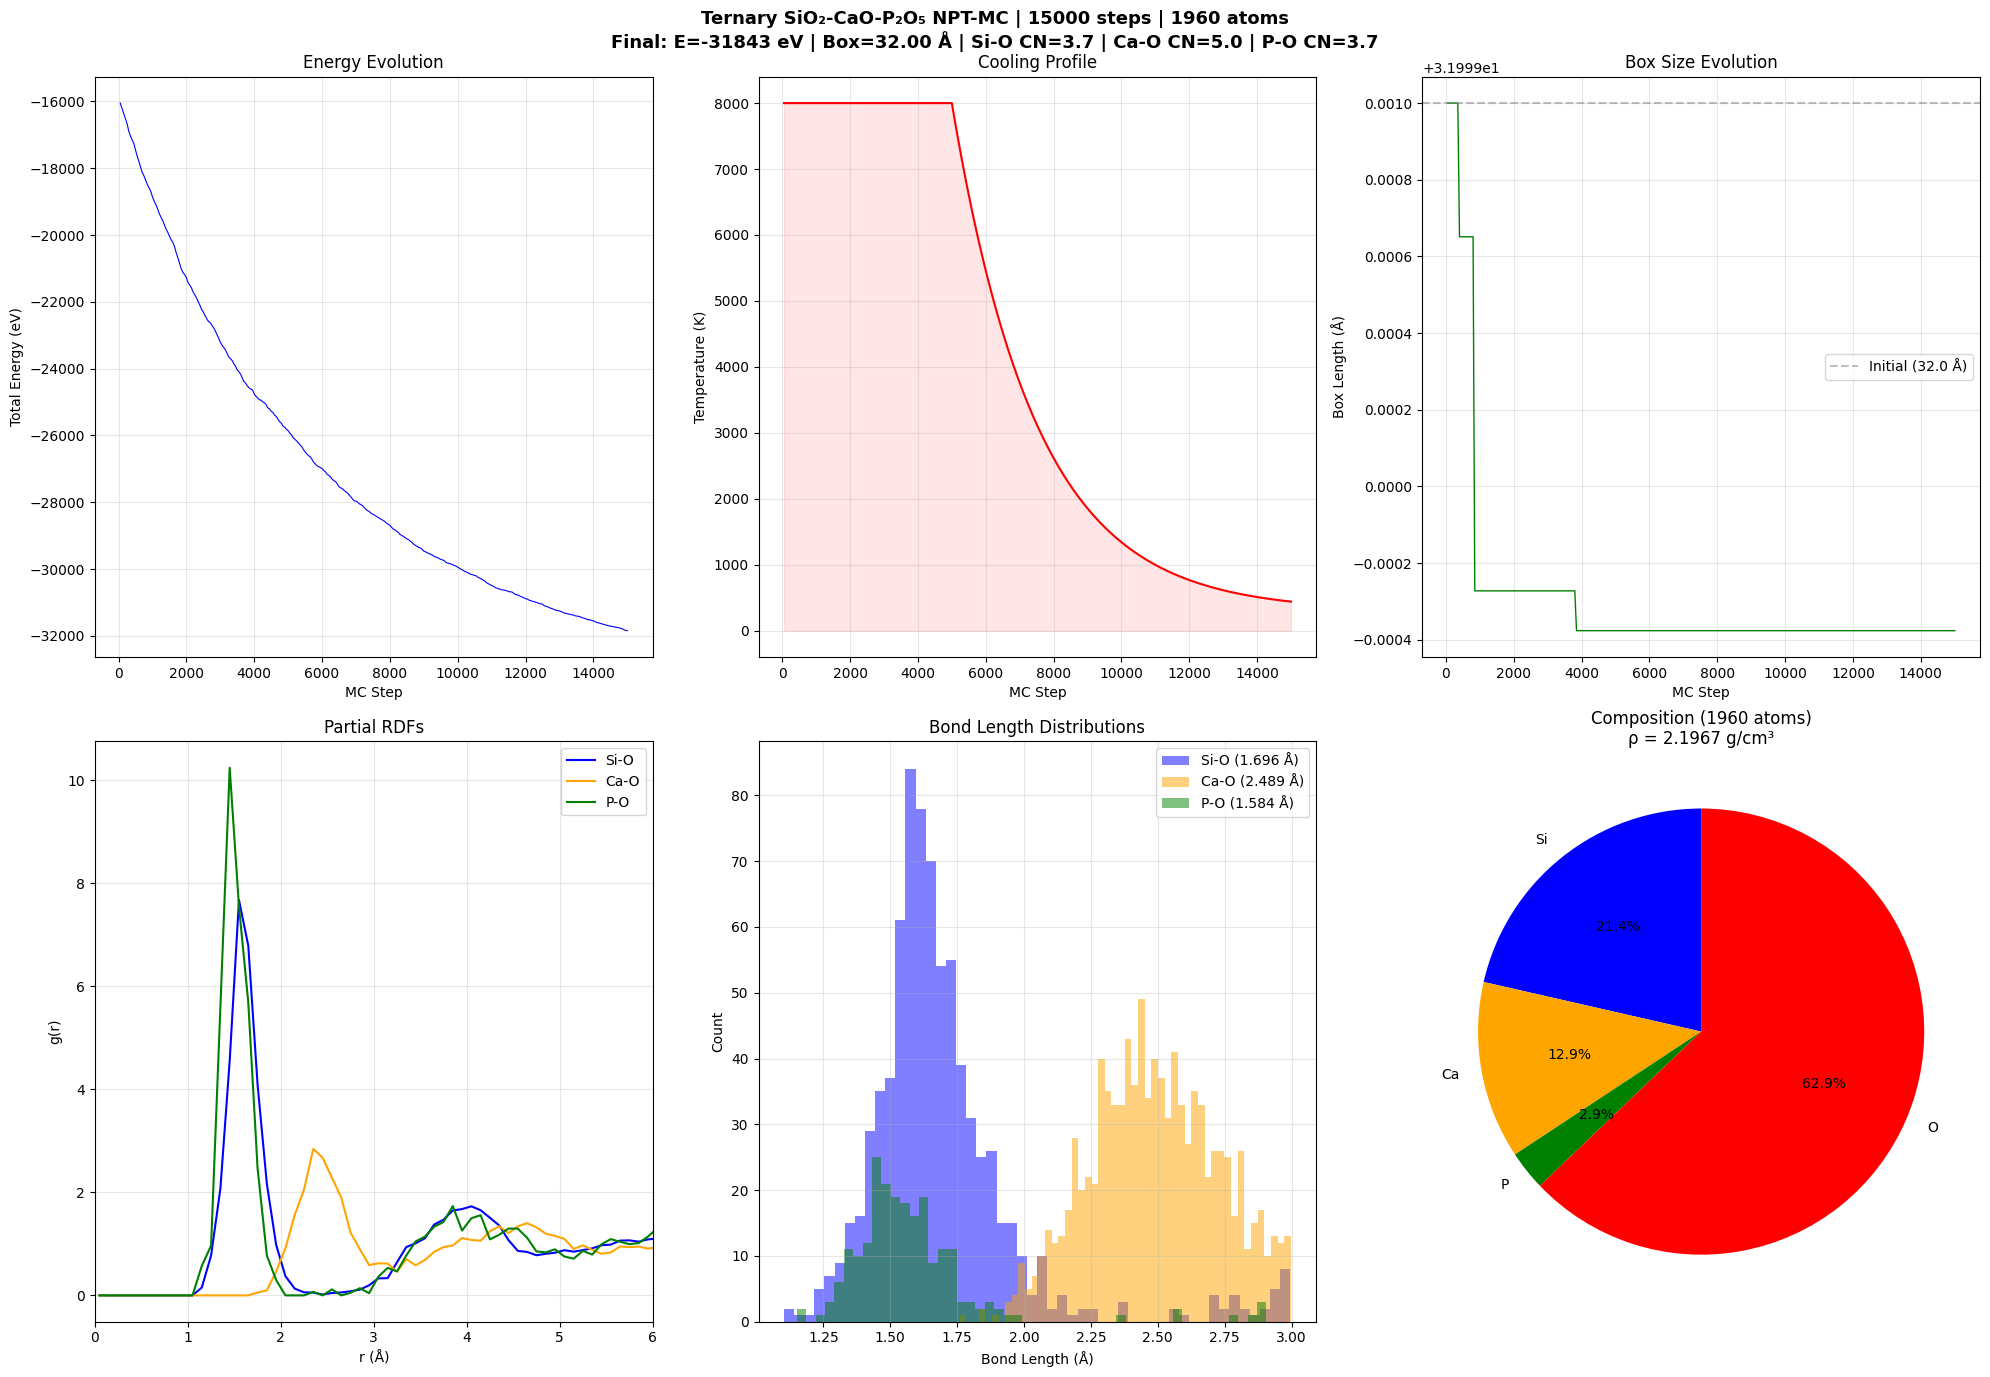

✓ Plot saved to ternary_analysis.png


In [95]:
# ============================================================
# Cell 8 (UPDATED): Analysis & Plots with CORRECT Density
# ============================================================
print("📊 Generating analysis...")

# ===== RDF =====
def compute_rdf(coords, types, box, type_i, type_j, dr=0.1, rmax=8.0):
    """RDF جزئی برای جفت اتم‌های خاص"""
    idx_i = np.where(types == type_i)[0]
    idx_j = np.where(types == type_j)[0] if type_i != type_j else idx_i
    
    n_i = len(idx_i); n_j = len(idx_j)
    if n_i == 0 or n_j == 0: return np.arange(0, rmax, dr), np.zeros(int(rmax/dr))
    
    rho_j = n_j / box**3
    bins = int(rmax/dr); hist = np.zeros(bins)
    
    tree = cKDTree(coords, boxsize=box)
    for i in idx_i:
        neighbors = tree.query_ball_point(coords[i], rmax)
        for j in neighbors:
            if types[j] == type_j and (type_i != type_j or i != j):
                rvec = coords[i] - coords[j]
                rvec = rvec - box * np.round(rvec/box)
                r = np.sqrt(np.sum(rvec**2))
                if r < rmax:
                    idx = int(r/dr)
                    if idx < bins: hist[idx] += 1
    
    rv = (np.arange(bins) + 0.5) * dr
    sv = 4 * np.pi * rv**2 * dr
    with np.errstate(divide='ignore', invalid='ignore'):
        g = np.where(sv > 0, hist / (n_i * rho_j * sv), 0.0)
    return rv, g

def compute_bond_length_distribution(coords, types, box, type_i, type_j, r_cut=3.0):
    """توزیع طول پیوند بین دو نوع اتم"""
    idx_i = np.where(types == type_i)[0]
    tree = cKDTree(coords, boxsize=box)
    bond_lengths = []
    
    for i in idx_i[:200]:  # نمونه‌گیری از ۲۰۰ اتم اول
        neighbors = tree.query_ball_point(coords[i], r_cut)
        for j in neighbors:
            if types[j] == type_j:
                rvec = coords[i] - coords[j]
                rvec = rvec - box * np.round(rvec/box)
                r = np.sqrt(np.sum(rvec**2))
                if r < r_cut:
                    bond_lengths.append(r)
    
    return np.array(bond_lengths)

# ===== محاسبه RDFها =====
r_sio, g_sio = compute_rdf(best_coords, types, best_box, 1, 0)  # Si-O
r_cao, g_cao = compute_rdf(best_coords, types, best_box, 2, 0)  # Ca-O
r_po, g_po = compute_rdf(best_coords, types, best_box, 3, 0)    # P-O
r_oo, g_oo = compute_rdf(best_coords, types, best_box, 0, 0)    # O-O

# ===== توزیع طول پیوند =====
bond_sio = compute_bond_length_distribution(best_coords, types, best_box, 1, 0)
bond_cao = compute_bond_length_distribution(best_coords, types, best_box, 2, 0)
bond_po = compute_bond_length_distribution(best_coords, types, best_box, 3, 0)

# ===== کئوردیناسیون‌ها =====
cn_si_o = compute_cn(best_coords, types, best_box, 1, 0)  # Si-O
cn_ca_o = compute_cn(best_coords, types, best_box, 2, 0)  # Ca-O
cn_p_o = compute_cn(best_coords, types, best_box, 3, 0)   # P-O

# ===== محاسبه دقیق چگالی =====
# وزن اتمی دقیق (g/mol)
mass_Si = 28.0855
mass_O = 15.9994
mass_Ca = 40.078
mass_P = 30.9738

# محاسبه تعداد هر اتم
n_Si = np.sum(types == 1)
n_O = np.sum(types == 0)
n_Ca = np.sum(types == 2)
n_P = np.sum(types == 3)

# جرم کل سیستم (گرم)
total_mass_grams = (n_Si*mass_Si + n_O*mass_O + n_Ca*mass_Ca + n_P*mass_P) / 6.022e23

# حجم باکس (cm³)
volume_cm3 = (best_box * 1e-8)**3  # تبدیل Å³ به cm³

# چگالی دقیق (g/cm³)
rho_exact = total_mass_grams / volume_cm3

# ترکیب شیمیایی
total_cations = n_Si + n_Ca + n_P
if total_cations > 0:
    mol_percent_Si = n_Si / total_cations * 100
    mol_percent_Ca = n_Ca / total_cations * 100
    mol_percent_P = n_P / total_cations * 100
else:
    mol_percent_Si = mol_percent_Ca = mol_percent_P = 0

print(f"\n{'='*60}")
print(f"RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  Final Energy:     {best_e:,.1f} eV")
print(f"  Final Box:        {best_box:.3f} Å")
print(f"  Box Volume:       {best_box**3:.1f} Å³ = {volume_cm3*1e24:.1f} cm³ × 10⁻²⁴")
print(f"\n  COMPOSITION:")
print(f"    Si: {n_Si} atoms ({mol_percent_Si:.1f} mol% of cations)")
print(f"    Ca: {n_Ca} atoms ({mol_percent_Ca:.1f} mol% of cations)")
print(f"    P:  {n_P} atoms ({mol_percent_P:.1f} mol% of cations)")
print(f"    O:  {n_O} atoms")
print(f"\n  EXACT DENSITY:    {rho_exact:.4f} g/cm³")
print(f"    (Bioactive glass 45S5: ~2.7 g/cm³)")
print(f"    (Pure SiO₂ glass:     ~2.2 g/cm³)")
print(f"\n  COORDINATION NUMBERS:")
print(f"    Si-O:  {cn_si_o:.2f} (target: 4.0 for tetrahedral SiO₄)")
print(f"    Ca-O:  {cn_ca_o:.2f} (target: 6-8 for network modifier)")
print(f"    P-O:   {cn_p_o:.2f} (target: 4.0 for phosphate PO₄)")
print(f"\n  BOND LENGTHS:")
print(f"    Si-O:  {np.mean(bond_sio):.4f} ± {np.std(bond_sio):.4f} Å (ref: 1.61 Å)")
print(f"    Ca-O:  {np.mean(bond_cao):.4f} ± {np.std(bond_cao):.4f} Å (ref: 2.3-2.5 Å)")
print(f"    P-O:   {np.mean(bond_po):.4f} ± {np.std(bond_po):.4f} Å (ref: 1.55 Å)")
print(f"{'='*60}")

# ===== نمودارها =====
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# Energy evolution
steps_plot = np.arange(1, len(energy_history)+1) * HISTORY_FREQ
axes[0,0].plot(steps_plot, energy_history, 'b-', lw=0.8)
axes[0,0].set(xlabel='MC Step', ylabel='Total Energy (eV)', title='Energy Evolution')
axes[0,0].grid(alpha=0.3)

# Temperature
axes[0,1].plot(steps_plot, temp_history, 'r-', lw=1.5)
axes[0,1].fill_between(steps_plot, 0, temp_history, alpha=0.1, color='red')
axes[0,1].set(xlabel='MC Step', ylabel='Temperature (K)', title='Cooling Profile')
axes[0,1].grid(alpha=0.3)

# Box size
axes[0,2].plot(steps_plot, box_history, 'g-', lw=1)
axes[0,2].axhline(BOX_INIT, color='gray', ls='--', alpha=0.5, label=f'Initial ({BOX_INIT} Å)')
axes[0,2].set(xlabel='MC Step', ylabel='Box Length (Å)', title='Box Size Evolution')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# RDFs
axes[1,0].plot(r_sio, g_sio, 'b-', lw=1.5, label='Si-O')
axes[1,0].plot(r_cao, g_cao, 'orange', lw=1.5, label='Ca-O')
axes[1,0].plot(r_po, g_po, 'green', lw=1.5, label='P-O')
axes[1,0].set(xlabel='r (Å)', ylabel='g(r)', title='Partial RDFs', xlim=(0, 6))
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Bond length distributions
axes[1,1].hist(bond_sio, bins=50, alpha=0.5, color='blue', label=f'Si-O ({np.mean(bond_sio):.3f} Å)')
axes[1,1].hist(bond_cao, bins=50, alpha=0.5, color='orange', label=f'Ca-O ({np.mean(bond_cao):.3f} Å)')
axes[1,1].hist(bond_po, bins=50, alpha=0.5, color='green', label=f'P-O ({np.mean(bond_po):.3f} Å)')
axes[1,1].set(xlabel='Bond Length (Å)', ylabel='Count', title='Bond Length Distributions')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

# Composition pie chart
axes[1,2].pie([n_Si, n_Ca, n_P, n_O], 
              labels=['Si', 'Ca', 'P', 'O'],
              colors=['blue', 'orange', 'green', 'red'],
              autopct='%1.1f%%', startangle=90)
axes[1,2].set(title=f'Composition ({n_atoms} atoms)\nρ = {rho_exact:.4f} g/cm³')

plt.suptitle(f'Ternary SiO₂-CaO-P₂O₅ NPT-MC | {N_STEPS} steps | {n_atoms} atoms\n'
             f'Final: E={best_e:.0f} eV | Box={best_box:.2f} Å | '
             f'Si-O CN={cn_si_o:.1f} | Ca-O CN={cn_ca_o:.1f} | P-O CN={cn_p_o:.1f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ternary_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to ternary_analysis.png")

In [96]:
# ============================================================
# Cell 9: Save Final Structure
# ============================================================
type_names = {0: 'O', 1: 'Si', 2: 'Ca', 3: 'P'}

with open("ternary_final.xyz", 'w') as f:
    f.write(f"{len(best_coords)}\n")
    f.write(f"Ternary SiO2-CaO-P2O5 NPT-MC {N_STEPS}steps "
            f"E={best_e:.1f}eV Box={best_box:.3f}A\n")
    for i in range(len(best_coords)):
        sym = type_names[types[i]]
        f.write(f"{sym} {best_coords[i,0]:.6f} {best_coords[i,1]:.6f} {best_coords[i,2]:.6f}\n")

print(f"✓ Final structure saved to ternary_final.xyz")

# Save trajectory
with open("ternary_trajectory.xyz", 'w') as f:
    for idx, frame in enumerate(trajectory_frames):
        f.write(f"{len(frame['coords'])}\n")
        f.write(f"Frame {idx+1} Step={frame['step']} T={frame['T']:.0f}K "
                f"E={frame['energy']:.1f}eV Box={frame['box']:.3f}A\n")
        for i in range(len(frame['coords'])):
            sym = type_names[types[i]]
            f.write(f"{sym} {frame['coords'][i,0]:.6f} {frame['coords'][i,1]:.6f} {frame['coords'][i,2]:.6f}\n")

print(f"✓ Trajectory saved to ternary_trajectory.xyz ({len(trajectory_frames)} frames)")

✓ Final structure saved to ternary_final.xyz
✓ Trajectory saved to ternary_trajectory.xyz (6 frames)
